# Lung Diseases — Deep End‑to‑End Classification (Multi‑Backbone) + Big Comparison Table + Grad‑CAM

This notebook implements the **second path**: **end‑to‑end deep learning classification** for lung images.

✅ **Multiple CNN backbones** (same as your Feature‑Extraction+ML path):  
- MobileNetV2  
- EfficientNetB0  
- ResNet50  
- DenseNet121  

✅ For **each backbone**:
- Train (frozen backbone) → optional fine‑tune (unfreeze top layers)
- Save best checkpoint
- Evaluate on **Val** and **Test**
- Store metrics into a **big comparison table**

✅ **Grad‑CAM** is generated for the **best deep model** (ranked by your chosen metric).

---

## Expected data structure

```
DATA_DIR/
  ClassA/
  ClassB/
  ClassC/
  ...
```

> Edit only `DATA_DIR` (and optionally `CLASS_ORDER`) then run all.


In [1]:
# ====== 0) Imports ======
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

print("TF:", tf.__version__)


TF: 2.20.0


## 1) Config (edit here)

If you want a fixed label order (recommended for thesis), set `CLASS_ORDER` explicitly.


In [3]:
# ====== 1) CONFIG ======
DATA_DIR = Path(r"D:\gradution project\Lung X-Ray Image")   # <-- EDIT THIS
OUTPUT_DIR = Path("./outputs_lung_deep")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.15
VAL_SIZE  = 0.15  # from remaining after test split

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 12
EPOCHS_FT   = 10

# Fine-tuning: unfreeze last N layers in the backbone
UNFREEZE_LAST_N = 30

# Optional: Fix class order (set to None to infer from folders in alphabetical order)
# Example:
# CLASS_ORDER = ["Normal", "Lung Opacity", "Viral Pneumonia"]
CLASS_ORDER = None

# Rank best model by:
RANK_BY = "val_f1_macro"  # val_accuracy / val_f1_macro / val_roc_auc_ovr

# Augmentation
AUGMENT = True

# Class imbalance handling (auto compute class_weight)
USE_CLASS_WEIGHTS = True

# Reproducibility
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("DATA_DIR:", DATA_DIR.resolve())


DATA_DIR: D:\gradution project\Lung X-Ray Image


## 2) Build file list + leakage‑free stratified split (saved to disk)

In [4]:
def list_image_files(data_dir: Path, class_order=None):
    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR not found: {data_dir}")

    class_dirs = [p for p in data_dir.iterdir() if p.is_dir()]
    if class_order is None:
        class_names = sorted([p.name for p in class_dirs])
    else:
        class_names = list(class_order)
        missing = [c for c in class_names if not (data_dir / c).exists()]
        if missing:
            raise ValueError(f"CLASS_ORDER has missing folders: {missing}")

    rows = []
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    for label, cname in enumerate(class_names):
        folder = data_dir / cname
        files = [p for p in folder.rglob("*") if p.suffix.lower() in exts]
        for f in files:
            rows.append({"path": str(f), "label": int(label), "class_name": cname})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No images found. Check DATA_DIR and extensions.")
    return df, class_names

df_all, CLASS_NAMES = list_image_files(DATA_DIR, CLASS_ORDER)
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Total images:", len(df_all))
df_all.head()


Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Total images: 3475


,path,label,class_name
0,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
1,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
2,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
3,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
4,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity


In [5]:
# Stratified train/val/test split
df_trainval, df_test = train_test_split(
    df_all, test_size=TEST_SIZE, random_state=SEED, stratify=df_all["label"]
)

val_frac_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_frac_of_trainval, random_state=SEED, stratify=df_trainval["label"]
)

print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))

# Save splits
splits_dir = OUTPUT_DIR / "splits"
splits_dir.mkdir(exist_ok=True, parents=True)
df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

with open(splits_dir / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"class_names": CLASS_NAMES}, f, ensure_ascii=False, indent=2)

pd.DataFrame({
    "split": ["train","val","test"],
    "n": [len(df_train), len(df_val), len(df_test)]
})


Train: 2431 Val: 522 Test: 522


,split,n
0,train,2431
1,val,522
2,test,522


## 3) tf.data pipeline (decode → resize → augmentation)

In [6]:
# Augmentation (train only)
augmenter = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.10),
    keras.layers.RandomContrast(0.10),
], name="augmenter")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32)
    return img, label

def make_ds(df: pd.DataFrame, training: bool):
    paths = df["path"].values
    labels = df["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y), num_parallel_calls=tf.data.AUTOTUNE)
    if training and AUGMENT:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

ds_train_raw = make_ds(df_train, training=True)
ds_val_raw   = make_ds(df_val, training=False)
ds_test_raw  = make_ds(df_test, training=False)

for xb, yb in ds_train_raw.take(1):
    print("Batch:", xb.shape, yb.shape, xb.dtype)


Batch: (32, 224, 224, 3) (32,) <dtype: 'float32'>


## 4) Class weights (optional)

In [7]:
def compute_class_weights(labels, num_classes):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    total = counts.sum()
    weights = total / (num_classes * np.maximum(counts, 1.0))
    return {i: float(w) for i, w in enumerate(weights)}

class_weight = None
if USE_CLASS_WEIGHTS:
    class_weight = compute_class_weights(df_train["label"].values, NUM_CLASSES)
    print("class_weight:", class_weight)
else:
    print("Class weights disabled.")


class_weight: {0: 1.0296484231948853, 1: 0.9271548390388489, 2: 1.052380919456482}


## 5) Backbones + preprocessing + model builder

In [8]:
from tensorflow.keras.applications import (
    MobileNetV2, EfficientNetB0, ResNet50, DenseNet121
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pp_mnv2
from tensorflow.keras.applications.efficientnet import preprocess_input as pp_effb0
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_res50
from tensorflow.keras.applications.densenet import preprocess_input as pp_d121

BACKBONES = {
    "MobileNetV2": (MobileNetV2, pp_mnv2),
    "EfficientNetB0": (EfficientNetB0, pp_effb0),
    "ResNet50": (ResNet50, pp_res50),
    "DenseNet121": (DenseNet121, pp_d121),
}

def build_deep_model(backbone_name: str, num_classes: int):
    ctor, preprocess = BACKBONES[backbone_name]
    base = ctor(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x = preprocess(inp)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.25)(x)
    out = keras.layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name=f"{backbone_name}_classifier")
    return model, base

def compile_model(model: keras.Model, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model


## 6) Helpers: evaluation metrics + ROC‑AUC (OvR)

In [9]:
def predict_probs(model, ds):
    probs = []
    ytrue = []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0)
        probs.append(pb)
        ytrue.append(yb.numpy())
    probs = np.concatenate(probs, axis=0)
    ytrue = np.concatenate(ytrue, axis=0)
    return ytrue, probs

def macro_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

def safe_roc_auc_ovr(y_true, probs, num_classes):
    try:
        if num_classes == 2:
            return float(roc_auc_score(y_true, probs[:, 1]))
        return float(roc_auc_score(y_true, probs, multi_class="ovr"))
    except Exception:
        return float("nan")


## 7) Train loop: for each backbone (Head training → Fine‑tune) + save + log metrics

In [10]:
models_dir = OUTPUT_DIR / "models"
runs_dir   = OUTPUT_DIR / "runs"
models_dir.mkdir(parents=True, exist_ok=True)
runs_dir.mkdir(parents=True, exist_ok=True)

all_runs = []

def train_one_backbone(backbone_name: str):
    print("\n" + "="*80)
    print("Backbone:", backbone_name)
    print("="*80)

    model, base = build_deep_model(backbone_name, NUM_CLASSES)
    model = compile_model(model, lr=1e-3)

    run_id = f"{backbone_name}__{int(time.time())}"
    run_out = runs_dir / run_id
    run_out.mkdir(parents=True, exist_ok=True)

    ckpt_path = models_dir / f"{backbone_name}__best.keras"

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_acc", mode="max", save_best_only=True, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_acc", mode="max", patience=4, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
    ]

    # ---- Phase 1: train head ----
    t0 = time.time()
    hist1 = model.fit(
        ds_train_raw,
        validation_data=ds_val_raw,
        epochs=EPOCHS_HEAD,
        callbacks=callbacks,
        class_weight=class_weight
    )
    time_head = time.time() - t0

    # ---- Phase 2: fine-tune ----
    base.trainable = True
    if UNFREEZE_LAST_N is not None and UNFREEZE_LAST_N > 0:
        for layer in base.layers[:-UNFREEZE_LAST_N]:
            layer.trainable = False

    model = compile_model(model, lr=1e-4)

    t1 = time.time()
    hist2 = model.fit(
        ds_train_raw,
        validation_data=ds_val_raw,
        epochs=EPOCHS_FT,
        callbacks=callbacks,
        class_weight=class_weight
    )
    time_ft = time.time() - t1

    # Load best checkpoint for evaluation
    best_model = keras.models.load_model(ckpt_path)

    # Evaluate on val/test
    yv, pv = predict_probs(best_model, ds_val_raw)
    yt, pt = predict_probs(best_model, ds_test_raw)

    yv_pred = pv.argmax(axis=1)
    yt_pred = pt.argmax(axis=1)

    val_m = macro_metrics(yv, yv_pred)
    test_m = macro_metrics(yt, yt_pred)

    val_roc = safe_roc_auc_ovr(yv, pv, NUM_CLASSES)
    test_roc = safe_roc_auc_ovr(yt, pt, NUM_CLASSES)

    # Save histories
    with open(run_out / "history_head.json", "w") as f:
        json.dump(hist1.history, f, indent=2)
    with open(run_out / "history_finetune.json", "w") as f:
        json.dump(hist2.history, f, indent=2)

    summary = {
        "run_id": run_id,
        "backbone": backbone_name,
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_head": EPOCHS_HEAD,
        "epochs_finetune": EPOCHS_FT,
        "unfreeze_last_n": UNFREEZE_LAST_N,
        "use_class_weights": USE_CLASS_WEIGHTS,
        "class_weight": class_weight,
        "val": {**val_m, "roc_auc_ovr": float(val_roc)},
        "test": {**test_m, "roc_auc_ovr": float(test_roc)},
        "time_head_sec": float(time_head),
        "time_finetune_sec": float(time_ft),
        "checkpoint_path": str(ckpt_path),
        "classes": CLASS_NAMES,
    }
    with open(run_out / "run_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    row = {
        "backbone": backbone_name,
        "val_accuracy": val_m["accuracy"],
        "val_precision_macro": val_m["precision_macro"],
        "val_recall_macro": val_m["recall_macro"],
        "val_f1_macro": val_m["f1_macro"],
        "val_roc_auc_ovr": float(val_roc),
        "test_accuracy": test_m["accuracy"],
        "test_precision_macro": test_m["precision_macro"],
        "test_recall_macro": test_m["recall_macro"],
        "test_f1_macro": test_m["f1_macro"],
        "test_roc_auc_ovr": float(test_roc),
        "time_head_sec": float(time_head),
        "time_finetune_sec": float(time_ft),
        "best_checkpoint": str(ckpt_path),
        "run_id": run_id,
    }
    return row

for bname in BACKBONES.keys():
    row = train_one_backbone(bname)
    all_runs.append(row)

comparison = pd.DataFrame(all_runs).sort_values(by=RANK_BY, ascending=False).reset_index(drop=True)
comparison_path = OUTPUT_DIR / "comparison_table.csv"
comparison.to_csv(comparison_path, index=False)

comparison



Backbone: MobileNetV2
Epoch 1/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - acc: 0.6752 - loss: 0.7200
Epoch 1: val_acc improved from -inf to 0.83716, saving model to outputs_lung_deep\models\MobileNetV2__best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 341ms/step - acc: 0.6764 - loss: 0.7179 - val_acc: 0.8372 - val_loss: 0.4418 - learning_rate: 0.0010
Epoch 2/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - acc: 0.8463 - loss: 0.3849
Epoch 2: val_acc improved from 0.83716 to 0.86973, saving model to outputs_lung_deep\models\MobileNetV2__best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 288ms/step - acc: 0.8464 - loss: 0.3847 - val_acc: 0.8697 - val_loss: 0.3217 - learning_rate: 0.0010
Epoch 3/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - acc: 0.8606 - loss: 0.3382
Epoch 3: val_acc improved from 0.86973 to 0.87548, saving model to outputs_lung_deep\models\MobileNetV2__best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 290ms/step - acc: 0.8606 - loss: 0.3381 - val_acc: 0.8755 - val_loss: 0.3137 - learning_rate: 

,backbone,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_ovr,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc_ovr,time_head_sec,time_finetune_sec,best_checkpoint,run_id
0,DenseNet121,0.923372,0.926018,0.924501,0.925196,0.985375,0.932950,0.934349,0.934164,0.934251,0.987564,2167.715462,810.981203,outputs_lung_deep\models\DenseNet121__best.keras,DenseNet121__1772032867
1,ResNet50,0.923372,0.932938,0.922213,0.925020,0.983885,0.915709,0.923496,0.914985,0.917915,0.983415,1444.089699,1242.461833,outputs_lung_deep\models\ResNet50__best.keras,ResNet50__1772030145
2,EfficientNetB0,0.921456,0.923888,0.922577,0.923135,0.978349,0.929119,0.929781,0.931160,0.930379,0.988817,276.014533,391.202790,outputs_lung_deep\models\EfficientNetB0__best....,EfficientNetB0__1772029455
3,MobileNetV2,0.908046,0.907809,0.910508,0.908750,0.978069,0.898467,0.898281,0.900901,0.899169,0.978605,293.928275,243.316275,outputs_lung_deep\models\MobileNetV2__best.keras,MobileNetV2__1772028902


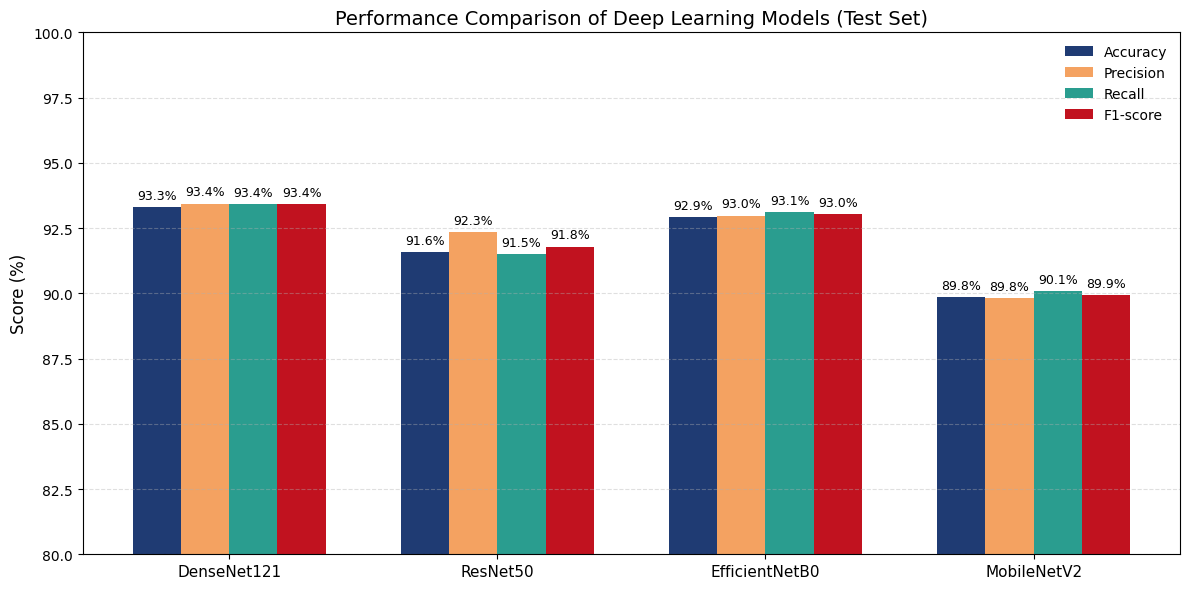

In [36]:
import numpy as np
import matplotlib.pyplot as plt

df = comparison.copy()

backbones = df["backbone"].values
accuracy = df["test_accuracy"].values * 100
precision = df["test_precision_macro"].values * 100
recall = df["test_recall_macro"].values * 100
f1 = df["test_f1_macro"].values * 100

x = np.arange(len(backbones))
width = 0.18

plt.figure(figsize=(12, 6))

# ألوان احترافية
colors = {
    "acc": "#1f3b73",     # Navy Blue
    "prec": "#f4a261",    # Soft Orange
    "rec": "#2a9d8f",     # Teal Green
    "f1": "#c1121f"       # Deep Red
}

bars1 = plt.bar(x - 1.5*width, accuracy, width, label="Accuracy", color=colors["acc"])
bars2 = plt.bar(x - 0.5*width, precision, width, label="Precision", color=colors["prec"])
bars3 = plt.bar(x + 0.5*width, recall, width, label="Recall", color=colors["rec"])
bars4 = plt.bar(x + 1.5*width, f1, width, label="F1-score", color=colors["f1"])

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                 f"{height:.1f}%", ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.xticks(x, backbones, fontsize=11)
plt.ylabel("Score (%)", fontsize=12)
plt.title("Performance Comparison of Deep Learning Models (Test Set)", fontsize=14)

plt.ylim(80, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()

# # حفظ بجودة عالية للثيسس
# plt.savefig("deep_models_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

## 8) Plot Top‑N comparison (Validation)

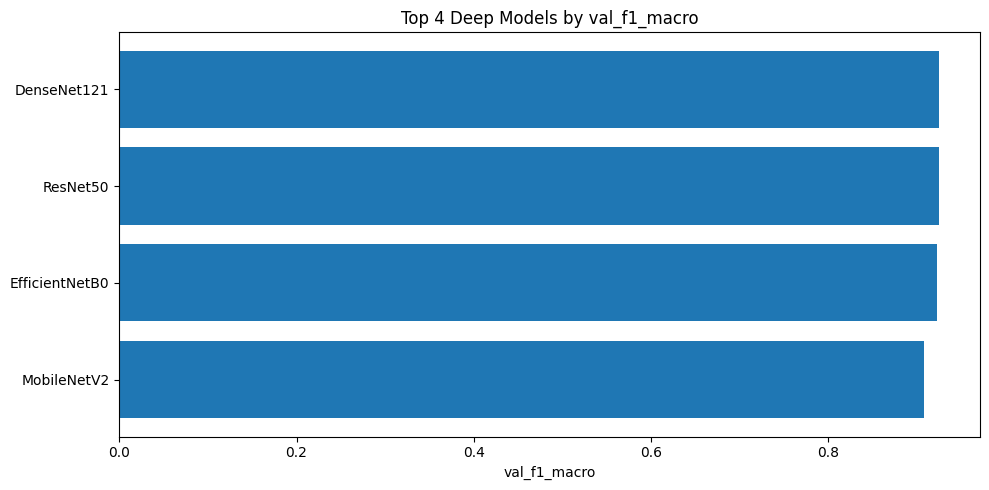

,backbone,val_f1_macro,test_f1_macro,test_accuracy,test_roc_auc_ovr
0,DenseNet121,0.925196,0.934251,0.932950,0.987564
1,ResNet50,0.925020,0.917915,0.915709,0.983415
2,EfficientNetB0,0.923135,0.930379,0.929119,0.988817
3,MobileNetV2,0.908750,0.899169,0.898467,0.978605


In [11]:
TOP_N = min(12, len(comparison))
metric = RANK_BY

top = comparison.head(TOP_N).copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top["backbone"][::-1], top[metric][::-1])
ax.set_xlabel(metric)
ax.set_title(f"Top {TOP_N} Deep Models by {metric}")
plt.tight_layout()
plt.show()

top[["backbone", metric, "test_f1_macro", "test_accuracy", "test_roc_auc_ovr"]]


## 9) Evaluate best deep model on Test (report + confusion matrix)

Best deep model: DenseNet121
                 precision    recall  f1-score   support

   Lung_Opacity       0.91      0.92      0.91       169
         Normal       0.91      0.91      0.91       188
Viral Pneumonia       0.98      0.98      0.98       165

       accuracy                           0.93       522
      macro avg       0.93      0.93      0.93       522
   weighted avg       0.93      0.93      0.93       522



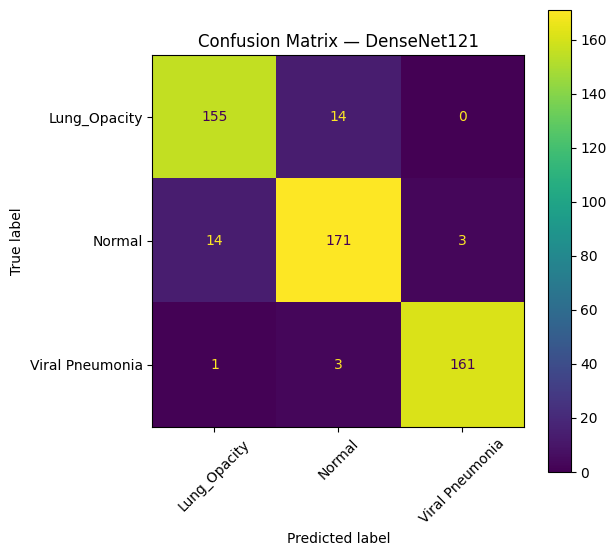

In [12]:
best = comparison.iloc[0].to_dict()
best_backbone = best["backbone"]
best_ckpt = best["best_checkpoint"]

best_model = keras.models.load_model(best_ckpt)

yt, pt = predict_probs(best_model, ds_test_raw)
yt_pred = pt.argmax(axis=1)

print("Best deep model:", best_backbone)
print(classification_report(yt, yt_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(yt, yt_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix — {best_backbone}")
plt.show()


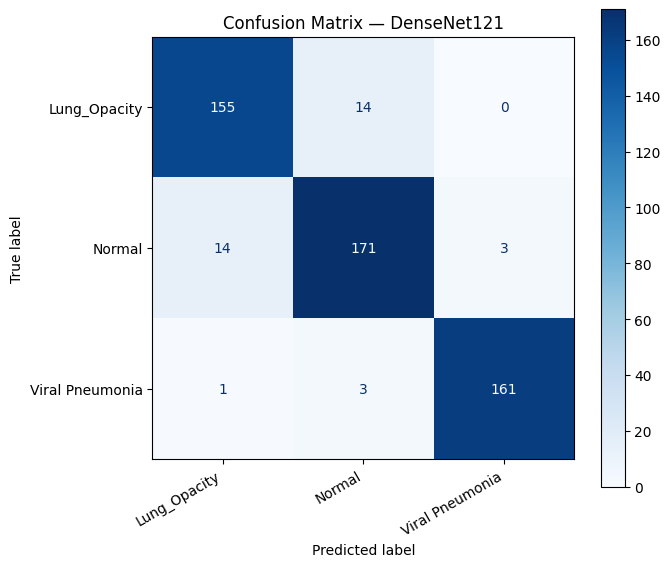

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yt, yt_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(
    ax=ax,
    cmap="Blues",          # غيّرها: "viridis" / "magma" / "Greens"
    colorbar=True,
    values_format="d"
)

ax.set_title(f"Confusion Matrix — {best_backbone}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 10) Grad‑CAM for the best model

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.
torchcam 0.4.0 requires numpy<2.0.0,>=1.17.2, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


CAM wrapper ready.
Picked per class: {'Lung_Opacity': 3, 'Normal': 3, 'Viral Pneumonia': 3}


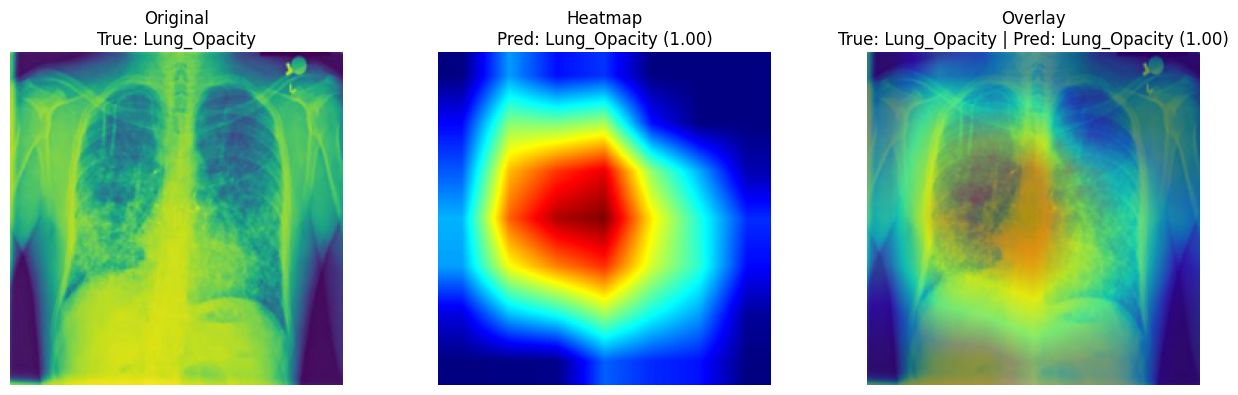

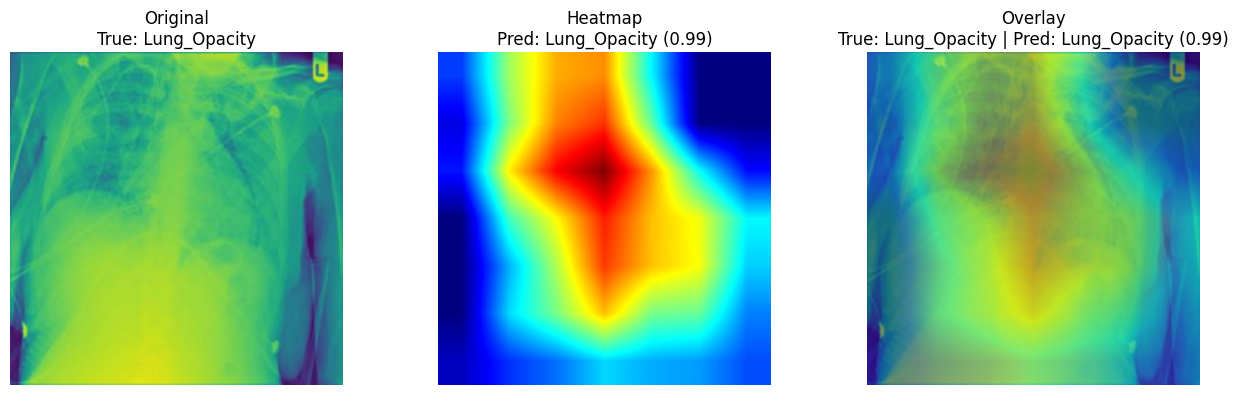

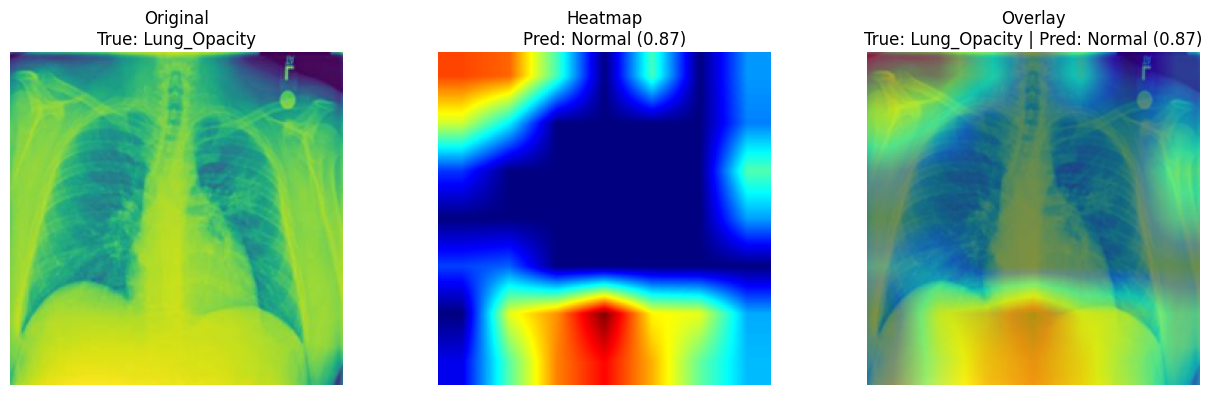

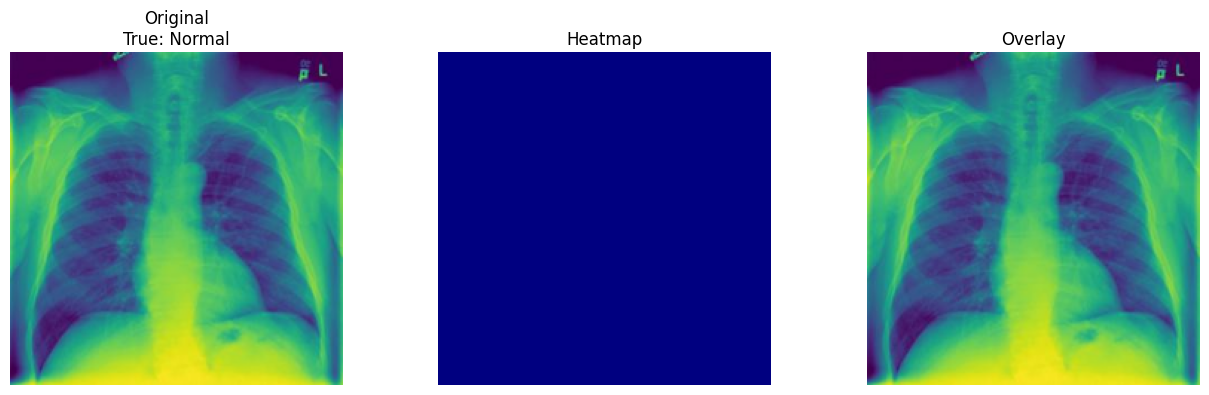

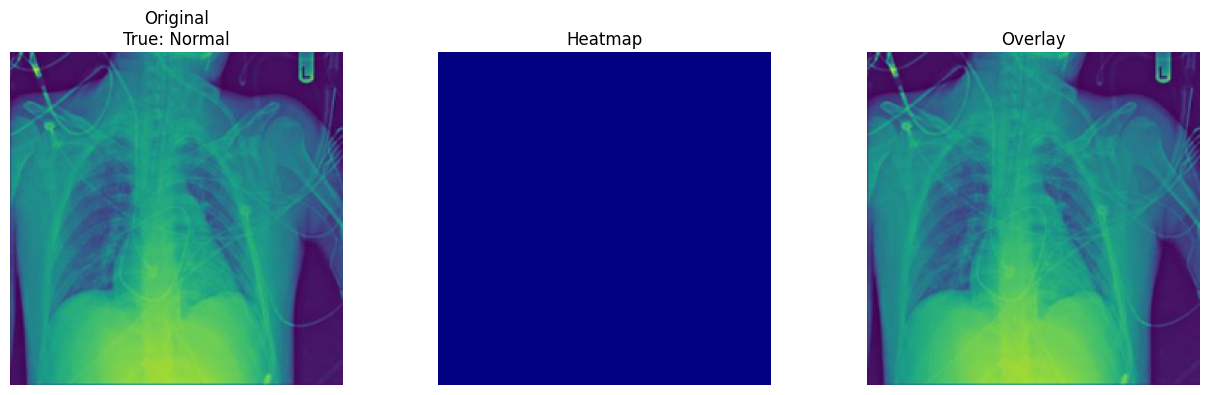

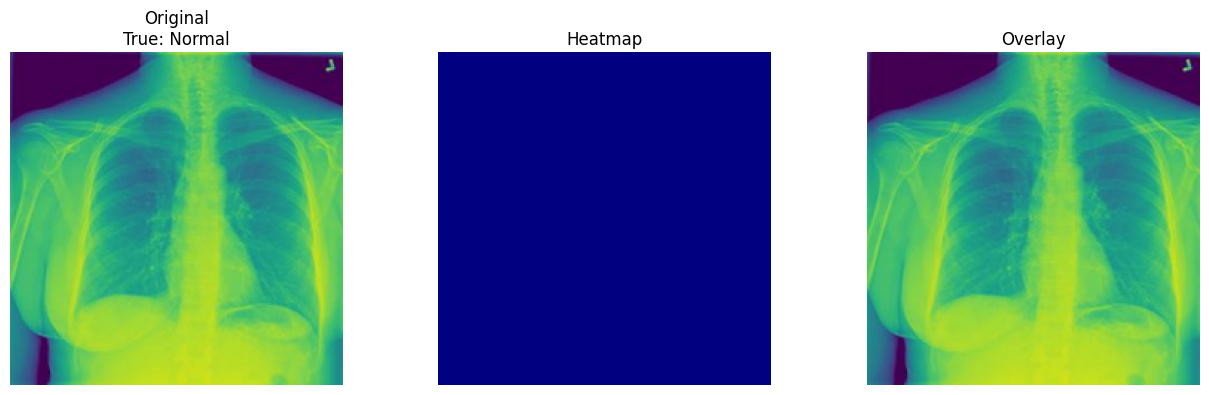

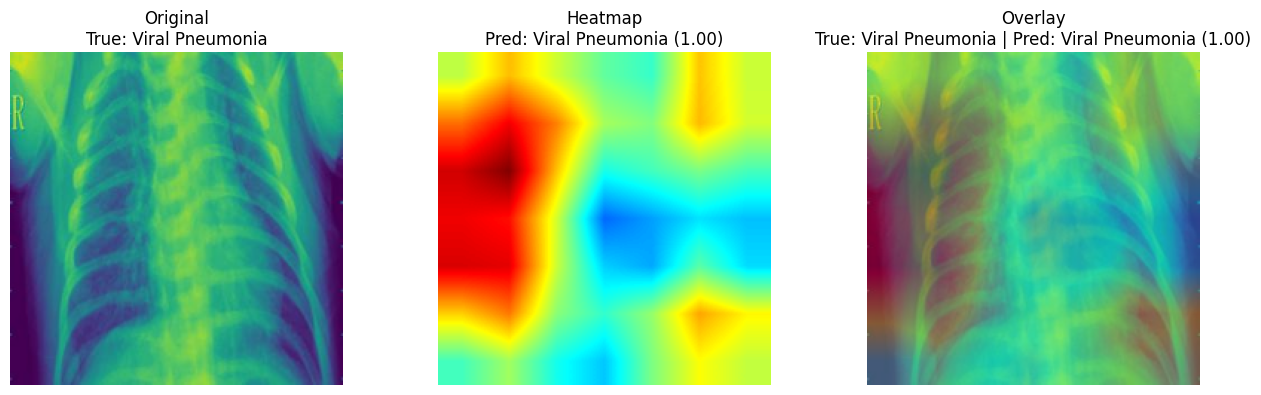

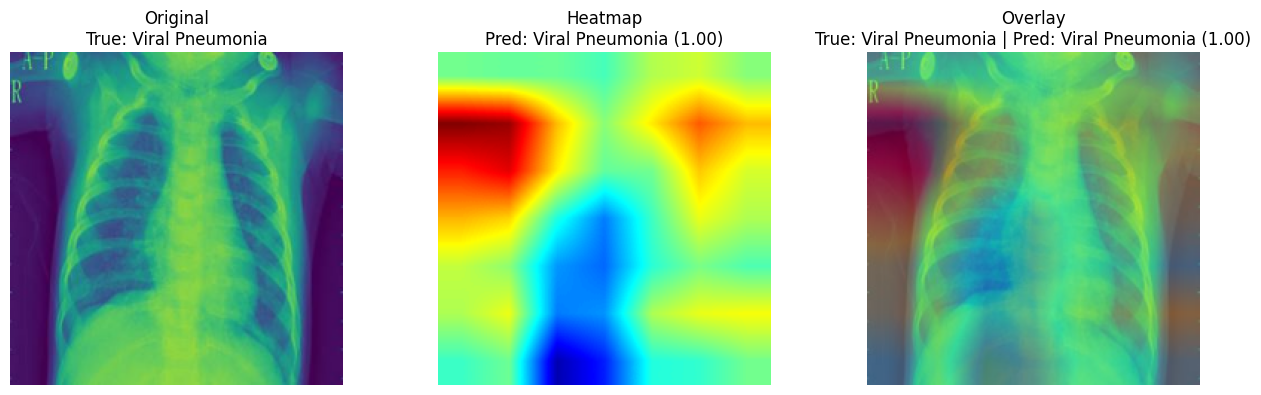

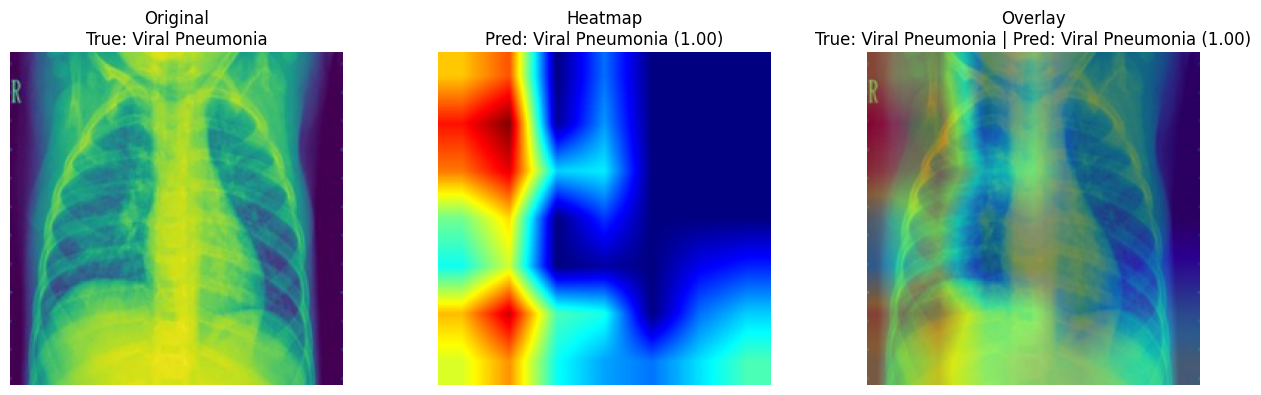

Saved outputs to: D:\gradution project\outputs_lung_deep\gradcam_custom


In [27]:
# =========================
# FULL DISPLAY + Grad-CAM (Keras 3 SAFE) + Custom Titles + N per class
# Best model: DenseNet121
# =========================

!pip -q install opencv-python

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as pp_d121

# -------- USER SETTINGS --------
NORMAL_CLASS_NAME = "Normal"   # غيّرها لو اسم الكلاس عندك مختلف
N_PER_CLASS = 3                # كام صورة من كل كلاس
ALPHA = 0.35                   # شدة الـ overlay
GAMMA = 0.7                    # يوضح السخن أكتر (0.6-0.9)
PENULTIMATE_LAYER = "conv5_block16_2_conv"  # آخر conv في DenseNet121
# --------------------------------

gradcam_dir = OUTPUT_DIR / "gradcam_custom"
gradcam_dir.mkdir(parents=True, exist_ok=True)

# ========= 1) Build DenseNet CAM wrapper and load weights from best_model =========
def build_densenet_cam_wrapper(num_classes: int):
    inp = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")

    x = pp_d121(inp)

    backbone = DenseNet121(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    backbone._name = "densenet121"

    conv_out = backbone.get_layer(PENULTIMATE_LAYER).output
    backbone_multi = keras.Model(backbone.input, [conv_out, backbone.output], name="densenet121_multi")

    conv_maps, bb_out = backbone_multi(x, training=False)

    gap = keras.layers.GlobalAveragePooling2D(name="global_average_pooling2d")(bb_out)
    drop = keras.layers.Dropout(0.25, name="dropout")(gap)
    preds = keras.layers.Dense(num_classes, activation="softmax", name="dense")(drop)

    cam_model = keras.Model(inp, [conv_maps, preds], name="DenseNet121_CAM_Wrapper")
    return cam_model

cam_model = build_densenet_cam_wrapper(NUM_CLASSES)
cam_model.set_weights(best_model.get_weights())
print("CAM wrapper ready.")

# ========= 2) Grad-CAM heatmap computation =========
def make_heatmap_from_conv_and_grads(conv_maps, grads):
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))      # (C,)
    heatmap = tf.reduce_sum(conv_maps * pooled_grads, axis=-1)  # (Hc,Wc)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap

# ========= 3) Visualization helpers =========
def normalize_heatmap_np(hm, eps=1e-8, gamma=0.7):
    hm = np.maximum(hm, 0)
    hm = hm / (hm.max() + eps)
    hm = np.power(hm, gamma)
    return hm

def colorize_heatmap(hm, img_size, gamma=0.7):
    hm = normalize_heatmap_np(hm, gamma=gamma)
    hm_uint8 = np.uint8(255 * hm)
    hm_uint8 = cv2.resize(hm_uint8, (img_size[1], img_size[0]))  # (W,H)
    heat_bgr = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)
    heat_rgb = cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)
    return heat_rgb

def to_uint8_rgb(img):
    if img.max() <= 1.0:
        img = img * 255.0
    return np.clip(img, 0, 255).astype(np.uint8)

def overlay_colored_heatmap(img_rgb_u8, heat_rgb_u8, alpha=0.35):
    overlay = img_rgb_u8 * (1 - alpha) + heat_rgb_u8 * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)

def show_triplet_custom(img, heatmap, img_size, true_name, pred_name, pred_prob,
                        alpha=0.35, gamma=0.7, normal_class_name="Normal"):
    img_u8 = to_uint8_rgb(img)

    # Normal: heatmap لون واحد + Heatmap title بس
    if true_name == normal_class_name:
        hm_fixed = np.zeros((img_size[0], img_size[1]), dtype=np.float32)  # كله 0 => أزرق
        heat_rgb = colorize_heatmap(hm_fixed, img_size, gamma=gamma)
        overlay = img_u8.copy()
        heat_title = "Heatmap"
        overlay_title = "Overlay"
    else:
        heat_rgb = colorize_heatmap(heatmap, img_size, gamma=gamma)
        overlay = overlay_colored_heatmap(img_u8, heat_rgb, alpha=alpha)
        heat_title = f"Heatmap\nPred: {pred_name} ({pred_prob:.2f})"
        overlay_title = f"Overlay\nTrue: {true_name} | Pred: {pred_name} ({pred_prob:.2f})"

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(img_u8); axes[0].axis("off")
    axes[0].set_title(f"Original\nTrue: {true_name}")

    axes[1].imshow(heat_rgb); axes[1].axis("off")
    axes[1].set_title(heat_title)

    axes[2].imshow(overlay if true_name != normal_class_name else img_u8); axes[2].axis("off")
    axes[2].set_title(overlay_title)

    plt.tight_layout()
    plt.show()

    return img_u8, heat_rgb, overlay

# ========= 4) Pick N images per class from test =========
picked = defaultdict(list)

for xb, yb in ds_test_raw.take(300):
    xb = xb.numpy()
    yb = yb.numpy()
    for i in range(xb.shape[0]):
        y = int(yb[i])
        if len(picked[y]) < N_PER_CLASS:
            picked[y].append(xb[i])
    if all(len(picked[c]) >= N_PER_CLASS for c in range(len(CLASS_NAMES))):
        break

print("Picked per class:", {CLASS_NAMES[k]: len(v) for k, v in picked.items()})

# ========= 5) Grad-CAM loop (per class) =========
for ytrue in range(len(CLASS_NAMES)):
    true_name = CLASS_NAMES[ytrue]
    for j, img in enumerate(picked[ytrue]):

        img_in = tf.convert_to_tensor(np.expand_dims(img, axis=0), dtype=tf.float32)

        # Prediction (from best_model)
        probs = best_model.predict(img_in, verbose=0)[0]
        ypred = int(np.argmax(probs))
        pred_prob = float(probs[ypred])
        pred_name = CLASS_NAMES[ypred]

        # Grad-CAM heatmap (from cam_model wrapper)
        with tf.GradientTape() as tape:
            conv_maps, preds = cam_model(img_in, training=False)
            cls = tf.argmax(preds[0])
            score = preds[:, cls]
            tape.watch(conv_maps)

        grads = tape.gradient(score, conv_maps)
        heatmap = make_heatmap_from_conv_and_grads(conv_maps[0], grads[0]).numpy()

        # Show with your custom rules
        img_u8, heat_rgb, overlay = show_triplet_custom(
            img=img,
            heatmap=heatmap,
            img_size=IMG_SIZE,
            true_name=true_name,
            pred_name=pred_name,
            pred_prob=pred_prob,
            alpha=ALPHA,
            gamma=GAMMA,
            normal_class_name=NORMAL_CLASS_NAME
        )

        # (اختياري) save overlay + heatmap colored
        out_base = gradcam_dir / f"class_{true_name}__{j:02d}__pred_{pred_name}__p_{pred_prob:.2f}"
        plt.imsave(str(out_base) + "_overlay.png", overlay if true_name != NORMAL_CLASS_NAME else img_u8)
        plt.imsave(str(out_base) + "_heatmap.png", heat_rgb)
        plt.imsave(str(out_base) + "_original.png", img_u8)

print("Saved outputs to:", gradcam_dir.resolve())

## 11) Next step

After you run:
- This notebook (Deep end‑to‑end)
- The Feature‑Extraction+ML notebook

Tell me and I’ll generate a **master thesis comparison table** combining both.
